In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans

In [155]:
df = pd.read_csv("Mall_Customers.csv")

display(df.head())
print(df.columns)

,CustomerID,Gender,Age,AnnualIncome,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Index(['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'Spending Score'], dtype='object')


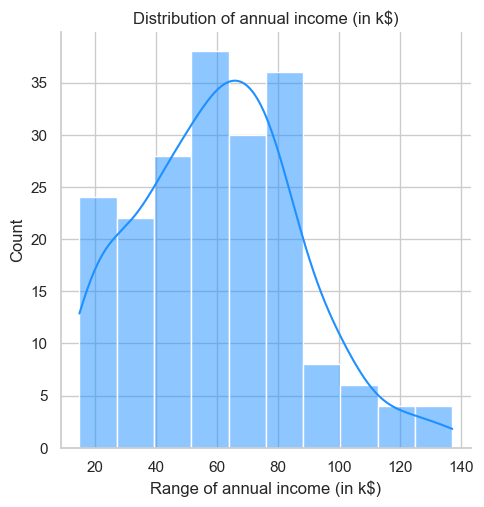

In [157]:
# distribution of annual income
sns.set(style="whitegrid")
sns.displot(df["AnnualIncome"], kde=True, color="dodgerblue")

plt.title("Distribution of annual income (in k$)")
plt.xlabel("Range of annual income (in k$)")
plt.ylabel("Count")

plt.show()

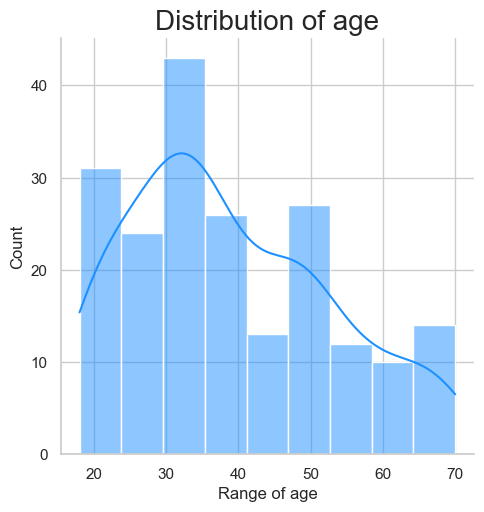

In [158]:
# distribution of age
sns.set(style="whitegrid")
sns.displot(df["Age"], kde=True, color="dodgerblue")

plt.title('Distribution of age', fontsize = 20)
plt.xlabel('Range of age')
plt.ylabel('Count')

plt.show()

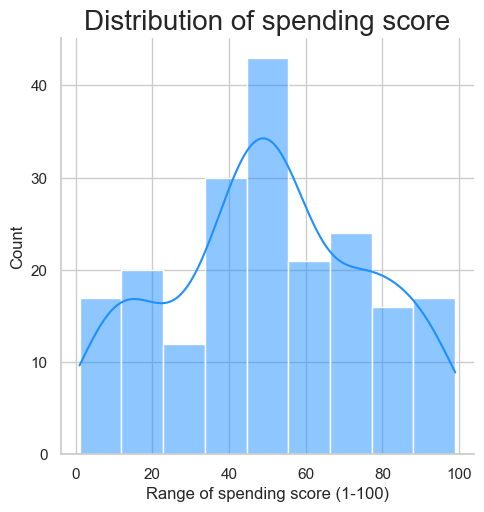

In [159]:
# distribution of spending score
sns.set(style="whitegrid")
sns.displot(df["Spending Score"], kde=True, color="dodgerblue")

plt.title('Distribution of spending score', fontsize = 20)
plt.xlabel('Range of spending score (1-100)')
plt.ylabel('Count')

plt.show()

In [160]:
X = df[["AnnualIncome", "Spending Score"]]
X.head()

,AnnualIncome,Spending Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


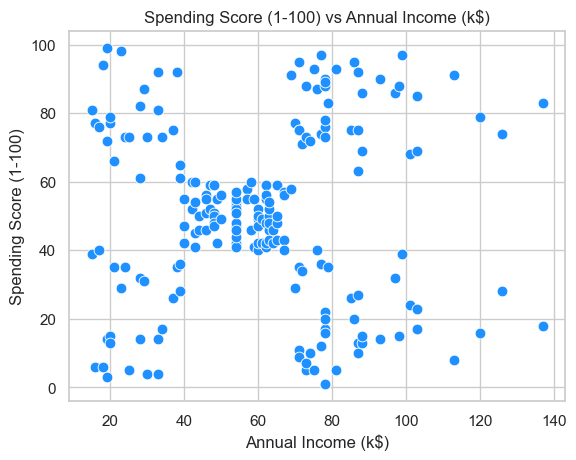

In [161]:
sns.scatterplot(x="AnnualIncome", y="Spending Score", data=X, s=60, color="dodgerblue")

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')

plt.show()

![Elbow Method](media/elbow-method.png)

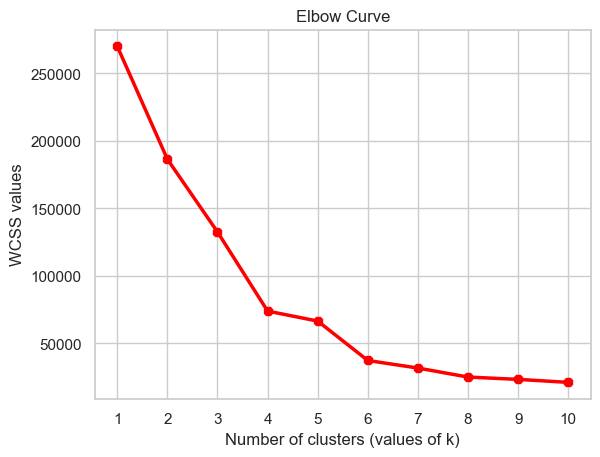

In [162]:
wcss = []
for i in range(1, 11):
    k_means = KMeans(n_clusters=i, n_init="auto")
    k_means.fit(X)
    wcss.append(k_means.inertia_)
    
plt.plot(range(1, 11), wcss)
plt.plot(range(1, 11), wcss, linewidth=2.5, color="red", marker="8")
plt.title("Elbow Curve")
plt.xlabel("Number of clusters (values of k)")
plt.ylabel("WCSS values")
plt.xticks(np.arange(1, 11, 1))
plt.show()

In [163]:
# taking k = 5
k_means_1 = KMeans(n_clusters=5, n_init="auto")
k_means_1.fit(X)
y_pred = k_means_1.predict(X)

df["label"] = y_pred

df.head()

,CustomerID,Gender,Age,AnnualIncome,Spending Score,label
0,1,Male,19,15,39,2
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2


### K Means from Scratch 

In [164]:
X = df[["AnnualIncome", "Spending Score"]].values

In [165]:
class K_Means:
    def __init__(self, k=5, tol=0.001, max_iter=300):
        self.k = k
        self.tol = tol
        self.max_iter = max_iter
    def fit(self,data):
        self.centroids = {}
        for i in range(self.k):
            self.centroids[i] = data[i]
            
        for i in range(self.max_iter):
            self.classifications = {}
            for i in range(self.k):
                self.classifications[i] = []

            for featureset in data:
                distances = [np.linalg.norm(featureset-self.centroids[centroid]) for centroid in self.centroids]
                classification = distances.index(min(distances))
                self.classifications[classification].append(featureset)
            
            prev_centroids = dict(self.centroids)
            
            for classification in self.classifications:
                self.centroids[classification] = np.average(self.classifications[classification],axis=0)
            optimized = True
            
            for c in self.centroids:
                original_centroid = prev_centroids[c]
                current_centroid = self.centroids[c]
                if np.sum((current_centroid-original_centroid)/original_centroid*100.0) > self.tol:
                    print(np.sum((current_centroid-original_centroid)/original_centroid*100.0))
                    optimized = False
            if optimized:
                break
    
    def predict(self,data):
        distances = [np.linalg.norm(data-self.centroids[centroid]) for centroid in self.centroids]
        classification = distances.index(min(distances))
        return classification

153.79972565157746
395.1388888888889
325.1043599257885
248.47839135654266
22.56410256410257
62.69598095187782
33.137241230781605
5.339844727017936
20.6651128086059
1.2260451171988616


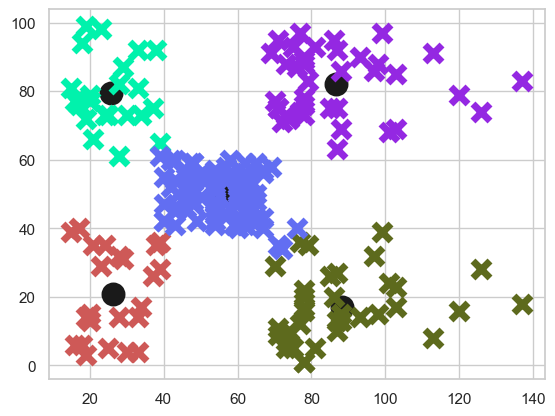

In [171]:
model = K_Means()
model.fit(X)
for centroid in model.centroids:
    plt.scatter(model.centroids[centroid][0], model.centroids[centroid][1],
                marker="o", color="k", s=150, linewidths=5)
def get_random_color():
    return (random.random(), random.random(), random.random())  # RGB tuple
for classification in model.classifications:
    color = get_random_color() 
    for featureset in model.classifications[classification]:
        plt.scatter(featureset[0], featureset[1], marker="x", color=color, s=150, linewidths=5)
plt.show()